In [1]:
# Cell 1: Imports

import os
from pathlib import Path
import math

import ipywidgets as widgets
from IPython.display import display

%matplotlib widget

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

from scipy.spatial.distance import cdist 
from scipy import linalg
import scipy.linalg
from scipy.ndimage import map_coordinates

print("numpy:", np.__version__)
print("PIL:", Image.__version__)
print("cv2:", cv2.__version__)
print("SciPy loaded successfully.")

numpy: 2.2.6
PIL: 10.2.0
cv2: 4.12.0
SciPy loaded successfully.


In [2]:
# Cell 2: Simplified Path Setup

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"

# Only create paths we actually need
DATA_RAW = DATA_DIR / "raw" / "OriginalImages"
DATA_LANDMARKS = DATA_DIR / "landmarks"
DATA_ALIGNED = DATA_DIR / "aligned"

# Create only essential directories
DATA_LANDMARKS.mkdir(parents=True, exist_ok=True)
DATA_ALIGNED.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_RAW:", DATA_RAW)
print("DATA_LANDMARKS:", DATA_LANDMARKS)
print("DATA_ALIGNED:", DATA_ALIGNED)
print("\n✓ Path setup complete")

PROJECT_ROOT: D:\Projects 2025\Caricature Generation
DATA_RAW: D:\Projects 2025\Caricature Generation\data\raw\OriginalImages
DATA_LANDMARKS: D:\Projects 2025\Caricature Generation\data\landmarks
DATA_ALIGNED: D:\Projects 2025\Caricature Generation\data\aligned

✓ Path setup complete


In [3]:
# Cell 3: Essential helper functions only

def load_landmarks(p):
    """Load landmarks from .npy file."""
    p = Path(p)
    if not p.exists():
        return None
    try:
        arr = np.load(str(p))
        if arr.ndim == 2 and arr.shape[1] == 2:
            return arr.astype(np.float32)
    except Exception as e:
        print(f"Error loading {p.name}: {e}")
    return None

def collect_photo_files(root_dir, limit=None):
    """Collect image files starting with 'p'."""
    files = []
    for img_path in root_dir.rglob('*'):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp'}:
            continue
        if not img_path.stem.lower().startswith('p'):
            continue
        files.append(img_path)
        if limit and len(files) >= limit:
            break
    return files

def bbox_diag(pts):
    """Calculate bounding box diagonal."""
    xs, ys = pts[:, 0], pts[:, 1]
    return np.linalg.norm([xs.max() - xs.min(), ys.max() - ys.min()])

def normalize_shape(pts):
    """Center and scale landmarks to unit size."""
    centroid = pts.mean(axis=0)
    scale = bbox_diag(pts)
    if scale < 1e-6:
        scale = 1.0
    return (pts - centroid) / scale

print("✓ Helper functions defined")

✓ Helper functions defined


In [4]:
# Cell 4: Landmark extraction
import face_alignment
from face_alignment import LandmarksType

DEMO_LIMIT = 100
DEVICE = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'

fa = face_alignment.FaceAlignment(LandmarksType.TWO_D, device=DEVICE, flip_input=False)

def get_largest_face(landmarks_list):
    """Return index of largest face."""
    areas = []
    for pts in landmarks_list:
        w = pts[:, 0].max() - pts[:, 0].min()
        h = pts[:, 1].max() - pts[:, 1].min()
        areas.append(w * h)
    return int(np.argmax(areas))

# Process images
all_files = collect_photo_files(DATA_RAW, DEMO_LIMIT)
print(f"Found {len(all_files)} images to process")

count_ok = 0
count_fail = 0

for img_path in tqdm(all_files, desc="Extracting landmarks"):
    rel_path = img_path.relative_to(DATA_RAW)
    out_path = DATA_LANDMARKS / rel_path.with_suffix('.npy')
    
    # Skip if already processed
    if out_path.exists():
        continue
    
    try:
        img = np.array(Image.open(img_path).convert('RGB'))
        preds = fa.get_landmarks(img)
        
        if preds is None or len(preds) == 0:
            count_fail += 1
            continue
        
        # Get largest face
        face_idx = get_largest_face(preds)
        pts = preds[face_idx].astype(np.float32)
        
        # Save landmarks only
        out_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(str(out_path), pts)
        count_ok += 1
        
    except Exception as e:
        count_fail += 1
        continue

print(f"\n{'='*60}")
print(f"✓ Success: {count_ok}")
print(f"✗ Failed: {count_fail}")
print(f"{'='*60}")

Found 100 images to process


Extracting landmarks: 100%|██████████████████████████████████████████████████████████| 100/100 [09:37<00:00,  5.78s/it]


✓ Success: 100
✗ Failed: 0


Scanning D:\Projects 2025\Caricature Generation\data\landmarks for landmarks...
Found 100 files. Using 100 shapes with 68 points.
✓ Saved to: D:\Projects 2025\Caricature Generation\data\aligned\mean_shape.npy


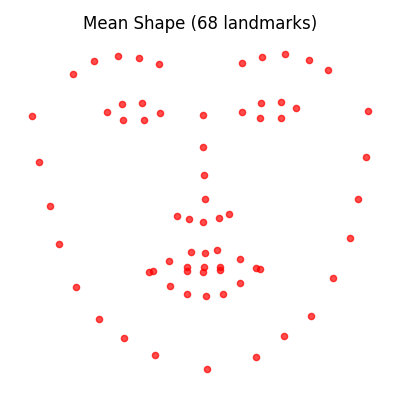

In [5]:
# Cell 5: Build mean normalized shape - single file output
MIN_LANDMARKS = 5
MEAN_SHAPE_PATH = DATA_ALIGNED / "mean_shape.npy"
DATA_ALIGNED.mkdir(parents=True, exist_ok=True)

def build_mean_shape(landmark_root=DATA_LANDMARKS):
    """Build mean normalized shape from landmarks."""
    all_norms = []
    counts = {}
    
    print(f"Scanning {landmark_root} for landmarks...")
    
    for lm_path in landmark_root.rglob("*.npy"):
        if not lm_path.stem.lower().startswith('p'):
            continue
        
        try:
            pts = np.load(str(lm_path))
            if pts.ndim != 2 or pts.shape[1] != 2 or pts.shape[0] < MIN_LANDMARKS:
                continue
            
            all_norms.append(normalize_shape(pts))
            counts[pts.shape[0]] = counts.get(pts.shape[0], 0) + 1
        except:
            continue
    
    if len(all_norms) == 0:
        raise RuntimeError("No valid landmarks found!")
    
    # Use most common landmark count
    common_n = max(counts, key=counts.get)
    final_norms = [n for n in all_norms if n.shape[0] == common_n]
    
    print(f"Found {len(all_norms)} files. Using {len(final_norms)} shapes with {common_n} points.")
    
    # Compute mean
    mean_norm = np.mean(np.stack(final_norms, axis=0), axis=0)
    np.save(MEAN_SHAPE_PATH, mean_norm)
    print(f"✓ Saved to: {MEAN_SHAPE_PATH}")
    
    return mean_norm

mean_norm = build_mean_shape()

# Visualize
plt.figure(figsize=(4, 4))
plt.scatter(mean_norm[:, 0], -mean_norm[:, 1], s=20, c='red', alpha=0.7)
plt.axis('equal')
plt.axis('off')
plt.title(f"Mean Shape ({len(mean_norm)} landmarks)")
plt.tight_layout()
plt.show()

In [6]:
# Cell 6: Create canonical target and transform utilities
OUTPUT_SIZE = (256, 256)
TARGET_FACE_SCALE = 0.45
TARGET_PTS_PATH = DATA_ALIGNED / "target_pts.npy"

# Load or use existing mean
if MEAN_SHAPE_PATH.exists():
    mean_norm = np.load(str(MEAN_SHAPE_PATH))
else:
    raise RuntimeError("Mean shape not found. Run Cell 5 first.")

# Create target points
w_out, h_out = OUTPUT_SIZE
center_out = np.array([w_out/2.0, h_out/2.0], dtype=np.float32)
target_scale = min(w_out, h_out) * TARGET_FACE_SCALE
target_pts = (mean_norm * target_scale + center_out).astype(np.float32)
np.save(str(TARGET_PTS_PATH), target_pts)
print(f"✓ Saved target_pts: {TARGET_PTS_PATH}")

def estimate_transform(src_pts, dst_pts, method='affine'):
    """Estimate transform with fallback strategies."""
    src = np.asarray(src_pts, dtype=np.float32)
    dst = np.asarray(dst_pts, dtype=np.float32)
    
    # Try RANSAC
    try:
        if method == 'affine':
            M, _ = cv2.estimateAffine2D(src, dst, method=cv2.RANSAC, 
                                        ransacReprojThreshold=5.0, maxIters=2000)
        else:
            M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC,
                                               ransacReprojThreshold=5.0, maxIters=2000)
        if M is not None:
            return M
    except:
        pass
    
    # Try LMEDS
    try:
        if method == 'affine':
            M, _ = cv2.estimateAffine2D(src, dst, method=cv2.LMEDS)
        else:
            M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
        if M is not None:
            return M
    except:
        pass
    
    # Fallback: simple similarity
    src_center = src.mean(axis=0)
    dst_center = dst.mean(axis=0)
    src_scale = np.sqrt(((src - src_center) ** 2).sum() / len(src))
    dst_scale = np.sqrt(((dst - dst_center) ** 2).sum() / len(dst))
    scale = dst_scale / (src_scale + 1e-8)
    
    M = np.array([
        [scale, 0, dst_center[0] - scale * src_center[0]],
        [0, scale, dst_center[1] - scale * src_center[1]]
    ], dtype=np.float32)
    
    return M

def transform_landmarks(pts, M):
    """Apply 2x3 affine matrix to landmarks."""
    pts = np.asarray(pts, dtype=np.float32)
    ones = np.ones((pts.shape[0], 1), dtype=np.float32)
    homog = np.concatenate([pts, ones], axis=1)
    return homog @ M.T

print("✓ Transform functions ready")

✓ Saved target_pts: D:\Projects 2025\Caricature Generation\data\aligned\target_pts.npy
✓ Transform functions ready


In [7]:
# Cell 7: Align images with hair preservation
ALIGNMENT_METHOD = 'affine'
CROP_STRATEGY = 'adaptive'
FACE_SCALE = 0.45
BG_FILL = (0, 0, 0)

def get_face_bbox_with_hair(pts, strategy='adaptive'):
    """Calculate bbox including hair region."""
    x_min, y_min = pts.min(axis=0)
    x_max, y_max = pts.max(axis=0)
    
    width = x_max - x_min
    height = y_max - y_min
    
    # Estimate hair region using anatomical proportions
    if len(pts) >= 27:
        eyebrow_top = pts[17:27, 1].min()
        jaw_bottom = pts[8, 1] if len(pts) > 8 else y_max
        face_height = jaw_bottom - eyebrow_top
        head_top_estimate = eyebrow_top - (face_height * 0.75)
    else:
        head_top_estimate = y_min - (height * 0.5)
    
    # Strategy-based padding
    if strategy == 'tight':
        pad_top = max(0, y_min - head_top_estimate) + height * 0.1
        pad_bottom = height * 0.1
        pad_x = width * 0.15
    elif strategy == 'adaptive':
        pad_top = max(0, y_min - head_top_estimate) + height * 0.25
        pad_bottom = height * 0.15
        pad_x = width * 0.25
    else:  # loose
        pad_top = max(0, y_min - head_top_estimate) + height * 0.45
        pad_bottom = height * 0.2
        pad_x = width * 0.35
    
    return [x_min - pad_x, y_min - pad_top, x_max + pad_x, y_max + pad_bottom]

def crop_and_align(img, pts, output_size, face_scale=0.45, crop_strategy='adaptive'):
    """Crop face with hair and align."""
    h_img, w_img = img.shape[:2]
    w_out, h_out = output_size
    
    # Get bbox
    bbox = get_face_bbox_with_hair(pts, strategy=crop_strategy)
    x_min, y_min, x_max, y_max = bbox
    
    # Clamp to image bounds
    x_min = max(0, int(x_min))
    y_min = max(0, int(y_min))
    x_max = min(w_img, int(x_max))
    y_max = min(h_img, int(y_max))
    
    # Crop
    cropped_img = img[y_min:y_max, x_min:x_max]
    cropped_pts = pts - np.array([x_min, y_min])
    
    # Calculate transform
    crop_center = np.array([cropped_img.shape[1] / 2, cropped_img.shape[0] / 2])
    target_center = np.array([w_out / 2, h_out / 2])
    
    face_w = cropped_pts[:, 0].max() - cropped_pts[:, 0].min()
    face_h = cropped_pts[:, 1].max() - cropped_pts[:, 1].min()
    target_scale = (min(w_out, h_out) * face_scale) / max(face_w, face_h)
    
    pts_centered = cropped_pts - crop_center
    target_pts_temp = pts_centered * target_scale + target_center
    
    M = estimate_transform(cropped_pts, target_pts_temp, method=ALIGNMENT_METHOD)
    
    # Warp
    warped = cv2.warpAffine(cropped_img, M, (w_out, h_out),
                            flags=cv2.INTER_LINEAR,
                            borderMode=cv2.BORDER_CONSTANT,
                            borderValue=BG_FILL)
    
    transformed_pts = transform_landmarks(cropped_pts, M)
    
    return warped, M, transformed_pts

# Process all images
raw_images = collect_photo_files(DATA_RAW, DEMO_LIMIT)
print(f"Found {len(raw_images)} images to align")

count_ok = 0
count_skipped = 0

for img_path in tqdm(raw_images, desc="Aligning with hair"):
    rel_path = img_path.relative_to(DATA_RAW)
    stem = rel_path.stem
    
    lm_src = DATA_LANDMARKS / rel_path.with_suffix('.npy')
    out_img = DATA_ALIGNED / f"{stem}_aligned.png"
    out_lm = DATA_ALIGNED / f"{stem}_aligned.npy"
    out_M = DATA_ALIGNED / f"{stem}_affine.npy"
    
    if not lm_src.exists():
        continue
    
    if out_img.exists() and out_lm.exists() and out_M.exists():
        count_skipped += 1
        continue
    
    try:
        src_pts = np.load(str(lm_src)).astype(np.float32)
        img = np.array(Image.open(img_path).convert('RGB'))
        
        warped, M, transformed_pts = crop_and_align(
            img, src_pts, OUTPUT_SIZE,
            face_scale=FACE_SCALE,
            crop_strategy=CROP_STRATEGY
        )
        
        out_img.parent.mkdir(parents=True, exist_ok=True)
        Image.fromarray(warped).save(str(out_img))
        np.save(str(out_lm), transformed_pts.astype(np.float32))
        np.save(str(out_M), M.astype(np.float32))
        
        count_ok += 1
    except Exception as e:
        continue

print(f"\n{'='*60}")
print(f"✓ Aligned: {count_ok}")
print(f"○ Skipped: {count_skipped}")
print(f"Output: {DATA_ALIGNED}")
print(f"{'='*60}")

Found 100 images to align


Aligning with hair: 100%|███████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 112.87it/s]


✓ Aligned: 36
○ Skipped: 64
Output: D:\Projects 2025\Caricature Generation\data\aligned


In [8]:
# CELL 8: Per-Feature Caricature Generator with Save
# ==================== CONFIGURATION ====================
DEMO_IMAGE_INDEX = 20

AVAILABLE_FEATURES = {
    'Left Eyebrow': list(range(17, 22)),
    'Right Eyebrow': list(range(22, 27)),
    'Nose': list(range(27, 36)),
    'Left Eye': list(range(36, 42)),
    'Right Eye': list(range(42, 48)),
    'Mouth': list(range(48, 68)),
    'Jaw': list(range(0, 17)),
}

SYMMETRY_PAIRS = [
    (list(range(17, 22)), list(range(22, 27))),
    (list(range(36, 42)), list(range(42, 48))),
    ([48, 49, 50], [54, 53, 52]),
    ([60, 61, 62], [64, 63, 62]),
]

BACKEND_SETTINGS = {
    'RBF_SIGMA': 40.0,
    'MIN_MOVEMENT_THRESHOLD': 2.0,
    'FALLOFF_RADIUS_FACTOR': 1.8,
    'FALLOFF_SHARPNESS': 2.0,
    'REG': 1e-2,
    'GRID_STEP': 2,
    'CANVAS_SCALE': 1.5,
    'LAMBDA_DISPLACEMENT': 0.15,
    'LAMBDA_SYMMETRY': 0.05,
    'LAMBDA_RATIO': 0.08,
    'LAMBDA_CROSSING': 0.15,
    'MAX_DISPLACEMENT_RATIO': 0.25,
    'NOSE_MAX_SCALE': 1.4,
}

# ==================== LOAD DATA ====================
ALIGNED_ROOT = Path(DATA_ALIGNED)
aligned_imgs = sorted(list(ALIGNED_ROOT.rglob("*_aligned.png")))
aligned_imgs = [p for p in aligned_imgs if p.stem.lower().startswith('p')]

if len(aligned_imgs) == 0:
    raise RuntimeError("No aligned images found.")

demo_img_path = aligned_imgs[DEMO_IMAGE_INDEX]
demo_lm_path = Path(str(demo_img_path).replace("_aligned.png", "_aligned.npy"))

img_original = np.array(Image.open(demo_img_path).convert("RGB"))
pts_original = np.load(str(demo_lm_path)).astype(np.float64)

mean_shape_path = Path(DATA_ALIGNED) / "target_pts.npy"
mean_shape = np.load(str(mean_shape_path)).astype(np.float64) if mean_shape_path.exists() else pts_original.copy()

print(f"✓ Loaded: {demo_img_path.name}")
print(f"✓ Image shape: {img_original.shape}")
print(f"✓ Landmarks shape: {pts_original.shape}")

# ==================== HELPER FUNCTIONS ====================
def expand_canvas(img, pts, scale=1.5):
    h, w = img.shape[:2]
    new_h = int(h * scale)
    new_w = int(w * scale)
    
    expanded = np.zeros((new_h, new_w, 3), dtype=img.dtype)  # This creates BLACK (0)
    
    offset_y = (new_h - h) // 2
    offset_x = (new_w - w) // 2
    
    expanded[offset_y:offset_y+h, offset_x:offset_x+w] = img
    
    pts_expanded = pts.copy()
    pts_expanded[:, 0] += offset_x
    pts_expanded[:, 1] += offset_y
    
    return expanded, pts_expanded, (offset_x, offset_y)

def crop_to_content(img, pts, margin=50):
    x_min, y_min = pts.min(axis=0).astype(int)
    x_max, y_max = pts.max(axis=0).astype(int)
    
    x_min = max(0, x_min - margin)
    y_min = max(0, y_min - margin)
    x_max = min(img.shape[1], x_max + margin)
    y_max = min(img.shape[0], y_max + margin)
    
    cropped = img[y_min:y_max, x_min:x_max]
    pts_cropped = pts.copy()
    pts_cropped[:, 0] -= x_min
    pts_cropped[:, 1] -= y_min
    
    return cropped, pts_cropped, (x_min, y_min)

def compute_facial_metrics(pts):
    left_eye_center = pts[36:42].mean(axis=0)
    right_eye_center = pts[42:48].mean(axis=0)
    eye_distance = np.linalg.norm(right_eye_center - left_eye_center)
    
    face_height = np.abs(pts[8, 1] - pts[27, 1])
    nose_width = np.abs(pts[31, 0] - pts[35, 0])
    mouth_width = np.abs(pts[48, 0] - pts[54, 0])
    
    return {
        'eye_distance': eye_distance,
        'face_height': face_height,
        'nose_width': nose_width,
        'mouth_width': mouth_width,
        'eye_nose_ratio': eye_distance / (nose_width + 1e-6),
        'eye_mouth_ratio': eye_distance / (mouth_width + 1e-6),
        'face_width_ratio': eye_distance / (face_height + 1e-6),
    }

def compute_displacement_loss(pts_original, pts_exag, max_displacement):
    displacements = np.linalg.norm(pts_exag - pts_original, axis=1)
    excess = np.maximum(0, displacements - max_displacement)
    return np.sum(excess ** 2)

def compute_symmetry_loss(pts_exag, symmetry_pairs):
    face_center_x = pts_exag[:, 0].mean()
    loss = 0.0
    
    for left_indices, right_indices in symmetry_pairs:
        if len(left_indices) != len(right_indices):
            continue
        
        for l_idx, r_idx in zip(left_indices, right_indices):
            left_pt = pts_exag[l_idx]
            right_pt = pts_exag[r_idx]
            
            left_offset = left_pt[0] - face_center_x
            right_offset = right_pt[0] - face_center_x
            
            symmetry_error = (left_offset + right_offset) ** 2
            y_error = (left_pt[1] - right_pt[1]) ** 2
            
            loss += symmetry_error + y_error
    
    return loss

def compute_ratio_loss(pts_original, pts_exag):
    metrics_orig = compute_facial_metrics(pts_original)
    metrics_exag = compute_facial_metrics(pts_exag)
    
    loss = 0.0
    for key in ['eye_nose_ratio', 'eye_mouth_ratio', 'face_width_ratio']:
        ratio_change = (metrics_exag[key] - metrics_orig[key]) ** 2
        loss += ratio_change
    
    return loss

def compute_crossing_penalty(pts_original, pts_exag):
    penalty = 0.0
    
    jaw_indices = list(range(0, 17))
    for i in range(len(jaw_indices) - 1):
        idx1, idx2 = jaw_indices[i], jaw_indices[i + 1]
        orig_order = np.sign(pts_original[idx2, 0] - pts_original[idx1, 0])
        exag_order = np.sign(pts_exag[idx2, 0] - pts_exag[idx1, 0])
        
        if orig_order * exag_order < 0:
            penalty += 1.0
    
    for eyebrow_indices in [range(17, 22), range(22, 27)]:
        for i in range(len(list(eyebrow_indices)) - 1):
            idx1 = list(eyebrow_indices)[i]
            idx2 = list(eyebrow_indices)[i + 1]
            orig_order = np.sign(pts_original[idx2, 0] - pts_original[idx1, 0])
            exag_order = np.sign(pts_exag[idx2, 0] - pts_exag[idx1, 0])
            
            if orig_order * exag_order < 0:
                penalty += 1.0
    
    return penalty * 100.0

def gaussian_rbf(distance, sigma):
    return np.exp(-(distance**2) / (2 * sigma**2))

def apply_selective_exaggeration(src_pts, mean_pts, feature_intensities, settings):
    movements = np.linalg.norm(mean_pts - src_pts, axis=1)
    
    landmark_intensity = np.zeros(len(src_pts))
    for feature_name, intensity in feature_intensities.items():
        if intensity > 0:
            indices = AVAILABLE_FEATURES[feature_name]
            for idx in indices:
                landmark_intensity[idx] = max(landmark_intensity[idx], intensity)
    
    landmark_exag_scale = 3.0 - (landmark_intensity / 5.0) * 1.8
    
    exag_mask = landmark_intensity > 0
    filtered_movements = movements.copy()
    filtered_movements[~exag_mask] = 0.0
    
    threshold = settings['MIN_MOVEMENT_THRESHOLD']
    significant = (filtered_movements > threshold) & exag_mask
    
    if not np.any(significant):
        return src_pts.copy(), {}
    
    active_pts = src_pts[significant]
    active_movements = filtered_movements[significant]
    max_movement = active_movements.max()
    weights = active_movements / (max_movement + 1e-8)
    
    face_bbox = src_pts.max(axis=0) - src_pts.min(axis=0)
    max_displacement = np.linalg.norm(face_bbox) * settings['MAX_DISPLACEMENT_RATIO']
    
    src_center = src_pts.mean(axis=0)
    pts_exag = src_pts.copy()
    sigma = settings['RBF_SIGMA']
    
    nose_indices = list(range(27, 36))
    
    for i in range(len(src_pts)):
        if not exag_mask[i]:
            continue
        
        dists = np.linalg.norm(src_pts[i] - active_pts, axis=1)
        rbf_values = gaussian_rbf(dists, sigma)
        local_factor = 1.0 + (rbf_values * weights).sum()
        
        combined_factor = 1.0 + (local_factor - 1.0) * landmark_exag_scale[i]
        
        if i in nose_indices:
            combined_factor = min(combined_factor, settings['NOSE_MAX_SCALE'])
        
        pts_exag[i] = src_center + combined_factor * (src_pts[i] - src_center)
    
    loss_displacement = compute_displacement_loss(src_pts, pts_exag, max_displacement)
    loss_symmetry = compute_symmetry_loss(pts_exag, SYMMETRY_PAIRS)
    loss_ratio = compute_ratio_loss(src_pts, pts_exag)
    loss_crossing = compute_crossing_penalty(src_pts, pts_exag)
    
    total_identity_loss = (
        settings['LAMBDA_DISPLACEMENT'] * loss_displacement +
        settings['LAMBDA_SYMMETRY'] * loss_symmetry +
        settings['LAMBDA_RATIO'] * loss_ratio +
        settings['LAMBDA_CROSSING'] * loss_crossing
    )
    
    damping_factor = 1.0
    if total_identity_loss > 0:
        damping_factor = 1.0 / (1.0 + 0.01 * total_identity_loss)
        damping_factor = max(0.6, min(1.0, damping_factor))
        pts_exag = src_pts + damping_factor * (pts_exag - src_pts)
    
    avg_intensity = np.mean(list(feature_intensities.values())) if feature_intensities else 0
    
    metrics = {
        'displacement': loss_displacement,
        'symmetry': loss_symmetry,
        'ratio': loss_ratio,
        'crossing': loss_crossing,
        'total': total_identity_loss,
        'damping': damping_factor,
        'avg_intensity': avg_intensity,
    }
    
    return pts_exag, metrics

def _tps_kernel(r):
    out = np.zeros_like(r, dtype=np.float64)
    nz = r > 0
    out[nz] = (r[nz]**2) * np.log(r[nz])
    return out

def solve_tps(ctrl_pts, target_vals, reg=1e-2):
    N = ctrl_pts.shape[0]
    diff = ctrl_pts[:, None, :] - ctrl_pts[None, :, :]
    r = np.sqrt((diff**2).sum(axis=2))
    K = _tps_kernel(r)
    P = np.concatenate([np.ones((N,1)), ctrl_pts], axis=1)
    A = np.zeros((N+3, N+3), dtype=np.float64)
    A[:N, :N] = K + reg * np.eye(N)
    A[:N, N:] = P
    A[N:, :N] = P.T
    rhs = np.zeros((N+3,), dtype=np.float64)
    rhs[:N] = target_vals.astype(np.float64)
    
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        coeffs = scipy.linalg.solve(A, rhs, assume_a='sym')
    
    return coeffs[:N], coeffs[N:]

def tps_eval_grid(ctrl_pts, w, a, xs, ys):
    XX, YY = np.meshgrid(xs, ys)
    pts = np.stack([XX.ravel(), YY.ravel()], axis=1)
    diff = pts[:, None, :] - ctrl_pts[None, :, :]
    r = np.sqrt((diff**2).sum(axis=2))
    U = _tps_kernel(r)
    fflat = U.dot(w) + a[0] + a[1]*pts[:,0] + a[2]*pts[:,1]
    return fflat.reshape(len(ys), len(xs))

def apply_tps_warp(img, src_pts, dst_pts, settings):
    h, w = img.shape[:2]
    
    if len(src_pts) != len(dst_pts):
        raise ValueError(f"Point count mismatch: {len(src_pts)} vs {len(dst_pts)}")
    
    w_x, a_x = solve_tps(dst_pts, src_pts[:,0], reg=settings['REG'])
    w_y, a_y = solve_tps(dst_pts, src_pts[:,1], reg=settings['REG'])
    
    grid_step = settings['GRID_STEP']
    xs_c = np.arange(0, w, grid_step, dtype=np.float32)
    ys_c = np.arange(0, h, grid_step, dtype=np.float32)
    
    map_xc = tps_eval_grid(dst_pts, w_x, a_x, xs_c, ys_c)
    map_yc = tps_eval_grid(dst_pts, w_y, a_y, xs_c, ys_c)
    
    map_x = cv2.resize(map_xc.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
    map_y = cv2.resize(map_yc.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
    
    id_x = np.tile(np.arange(w, dtype=np.float32)[None, :], (h, 1))
    id_y = np.tile(np.arange(h, dtype=np.float32)[:, None], (1, w))
    
    centroid = src_pts.mean(axis=0)
    bbox_diag = np.linalg.norm([src_pts[:,0].max()-src_pts[:,0].min(), 
                                src_pts[:,1].max()-src_pts[:,1].min()])
    radius = bbox_diag * settings['FALLOFF_RADIUS_FACTOR'] if bbox_diag > 1e-6 else max(h,w)*0.25
    
    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    dist = np.sqrt((xx - centroid[0])**2 + (yy - centroid[1])**2)
    weight = np.exp(- (dist / (radius + 1e-8))**2 * settings['FALLOFF_SHARPNESS']).astype(np.float32)
    
    final_map_x = (1.0 - weight) * id_x + weight * map_x
    final_map_y = (1.0 - weight) * id_y + weight * map_y
    
    final_map_x = np.clip(final_map_x, 0.0, float(w-1))
    final_map_y = np.clip(final_map_y, 0.0, float(h-1))
    
    src_u8 = np.clip(img, 0, 255).astype(np.uint8)
    warped = cv2.remap(src_u8, final_map_x, final_map_y, 
                      interpolation=cv2.INTER_LINEAR,
                      borderMode=cv2.BORDER_REPLICATE)
    
    if warped is None or warped.size == 0:
        print("⚠️ Warning: Warp failed, returning original")
        return img, weight
    
    return warped, weight

# ==================== GLOBAL STORAGE FOR NEXT CELL ====================
# These will store data to pass to the blending cell
SAVED_ORIGINAL_FULL = None
SAVED_WARPED_FULL = None
SAVED_CROP_COORDS = None

# ==================== UI ====================
class PerFeatureCaricatureApp:
    def __init__(self):
        self.settings = BACKEND_SETTINGS.copy()
        self.current_warped = None
        self.current_original_cropped = None
        self.current_crop_coords = None
        self.current_metrics = {}
        
        self.output = widgets.Output()
        self.save_output = widgets.Output()
        
        self.feature_sliders = {}
        for feature_name in AVAILABLE_FEATURES.keys():
            slider = widgets.IntSlider(
                value=0,
                min=0,
                max=5,
                step=1,
                description=feature_name + ':',
                style={'description_width': '120px'},
                layout=widgets.Layout(width='400px'),
                readout_format='d'
            )
            slider.observe(self.on_change, names='value')
            self.feature_sliders[feature_name] = slider
        
        self.save_button = widgets.Button(
            description='💾 Save & Send to Blending',
            button_style='success',
            layout=widgets.Layout(width='250px', height='40px')
        )
        self.save_button.on_click(self.save_and_transfer)
        
        sliders_box = widgets.VBox([
            widgets.HTML("<h3>🎨 Feature Exaggeration Controls</h3>"),
            widgets.HTML("<p style='color: #666; font-size: 12px;'>Level 0 = no change | Level 5 = maximum exaggeration</p>")
        ] + list(self.feature_sliders.values()))
        
        controls = widgets.VBox([
            sliders_box,
            self.save_button,
            self.save_output
        ])
        
        self.ui = widgets.VBox([controls, self.output])
        self.update()
    
    def get_feature_intensities(self):
        return {name: slider.value for name, slider in self.feature_sliders.items()}
    
    def on_change(self, change):
        self.update()
    
    def save_and_transfer(self, button):
        global SAVED_ORIGINAL_FULL, SAVED_WARPED_FULL, SAVED_CROP_COORDS
        
        with self.save_output:
            self.save_output.clear_output()
            
            if self.current_warped is None:
                print("⚠️ No result to save. Generate a caricature first.")
                return
            
            try:
                # Store for next cell
                SAVED_WARPED_FULL = self.current_warped.copy()
                SAVED_ORIGINAL_FULL = self.current_original_cropped.copy()
                SAVED_CROP_COORDS = self.current_crop_coords
                
                # Also save to disk
                output_dir = Path(DATA_ALIGNED).parent / "caricatures_for_blending"
                output_dir.mkdir(parents=True, exist_ok=True)
                
                base_name = demo_img_path.stem.replace('_aligned', '')
                intensities = self.get_feature_intensities()
                active_features = [name for name, val in intensities.items() if val > 0]
                
                if active_features:
                    features_str = "_".join([f"{name.replace(' ', '')}_{intensities[name]}" 
                                            for name in active_features[:3]])
                else:
                    features_str = "original"
                
                warped_path = output_dir / f"{base_name}_warped_{features_str}.png"
                original_path = output_dir / f"{base_name}_original_cropped_{features_str}.png"
                
                Image.fromarray(SAVED_WARPED_FULL).save(str(warped_path))
                Image.fromarray(SAVED_ORIGINAL_FULL).save(str(original_path))
                
                print(f"✅ Saved to disk:")
                print(f"   📄 Warped: {warped_path.name}")
                print(f"   📄 Original: {original_path.name}")
                print(f"\n✅ Data transferred to global variables:")
                print(f"   SAVED_WARPED_FULL: {SAVED_WARPED_FULL.shape}")
                print(f"   SAVED_ORIGINAL_FULL: {SAVED_ORIGINAL_FULL.shape}")
                print(f"\n🎨 Active features: {', '.join([f'{n}(L{intensities[n]})' for n in active_features]) if active_features else 'None'}")
                print(f"\n▶️ Ready for Laplacian Pyramid Blending! Run the next cell.")
                
            except Exception as e:
                print(f"❌ Error: {e}")
                import traceback
                traceback.print_exc()
    
    def update(self):
        feature_intensities = self.get_feature_intensities()
        
        with self.output:
            self.output.clear_output(wait=True)
            
            if all(val == 0 for val in feature_intensities.values()):
                print("ℹ️ All features set to Level 0 - showing original image")
                print("💡 Increase any feature slider to see exaggeration")
                
                fig, ax = plt.subplots(1, 1, figsize=(8, 8))
                ax.imshow(img_original)
                ax.scatter(pts_original[:,0], pts_original[:,1], c='red', s=15, alpha=0.6)
                ax.set_title('Original Image (No Exaggeration)', fontsize=14, fontweight='bold')
                ax.axis('off')
                plt.tight_layout()
                plt.show()
                return
            
            try:
                img_expanded, pts_expanded, offset = expand_canvas(
                    img_original, pts_original, self.settings['CANVAS_SCALE']
                )
                mean_expanded = mean_shape.copy()
                mean_expanded[:, 0] += offset[0]
                mean_expanded[:, 1] += offset[1]
                
                pts_exag, metrics = apply_selective_exaggeration(
                    pts_expanded, mean_expanded, feature_intensities, self.settings
                )
                self.current_metrics = metrics
                
                warped, _ = apply_tps_warp(img_expanded, pts_expanded, pts_exag, self.settings)
                
                warped_cropped, pts_exag_cropped, crop_coords = crop_to_content(warped, pts_exag, margin=50)
                
                # Crop original to same region
                x_min, y_min = crop_coords
                x_max = x_min + warped_cropped.shape[1]
                y_max = y_min + warped_cropped.shape[0]
                original_cropped = img_expanded[y_min:y_max, x_min:x_max]
                
                self.current_warped = warped_cropped
                self.current_original_cropped = original_cropped
                self.current_crop_coords = crop_coords
                
                h_orig, w_orig = img_original.shape[:2]
                h_crop, w_crop = warped_cropped.shape[:2]
                
                fig = plt.figure(figsize=(12, 6))
                
                ax1 = plt.subplot(1, 2, 1)
                ax1.imshow(img_original)
                ax1.scatter(pts_original[:,0], pts_original[:,1], c='red', s=15, alpha=0.6)
                
                for feature_name, intensity in feature_intensities.items():
                    if intensity > 0:
                        indices = AVAILABLE_FEATURES[feature_name]
                        for i in indices:
                            ax1.scatter(pts_original[i,0], pts_original[i,1], 
                                       c='lime', s=40, marker='o', edgecolors='black', 
                                       linewidths=2, alpha=min(1.0, intensity/2.5), zorder=10)
                
                ax1.set_title('Original Image', fontsize=14, fontweight='bold', pad=10)
                ax1.axis('off')
                ax1.set_xlim(0, w_orig)
                ax1.set_ylim(h_orig, 0)
                
                ax2 = plt.subplot(1, 2, 2)
                ax2.imshow(warped_cropped)
                
                active_features = [f"{name} (L{val})" for name, val in feature_intensities.items() if val > 0]
                title = f'Caricature Result (TPS)\n{", ".join(active_features[:2])}'
                if len(active_features) > 2:
                    title += f' +{len(active_features)-2} more'
                
                ax2.set_title(title, fontsize=14, fontweight='bold', pad=10)
                ax2.axis('off')
                ax2.set_xlim(0, w_crop)
                ax2.set_ylim(h_crop, 0)
                
                plt.tight_layout()
                plt.show()
                
                active_count = sum(1 for val in feature_intensities.values() if val > 0)
                avg_intensity = metrics.get('avg_intensity', 0)
                print(f"✅ Processed | Active features: {active_count} | "
                      f"Avg level: {avg_intensity:.1f} | "
                      f"Output: {warped_cropped.shape[1]}x{warped_cropped.shape[0]}")
                print(f"💡 Click 'Save & Send to Blending' to fix edge artifacts!")
                
            except Exception as e:
                print(f"❌ Error: {e}")
                import traceback
                traceback.print_exc()
    
    def display(self):
        display(self.ui)

app = PerFeatureCaricatureApp()
app.display()

print("\n✅ Per-Feature Caricature Generator Ready!")
print("🎨 Each feature has 5 levels of exaggeration (0-5)")
print("💾 Click 'Save & Send to Blending' to prepare for edge fixing!")

✓ Loaded: P00021_aligned.png
✓ Image shape: (256, 256, 3)
✓ Landmarks shape: (68, 2)



✅ Per-Feature Caricature Generator Ready!
🎨 Each feature has 5 levels of exaggeration (0-5)
💾 Click 'Save & Send to Blending' to prepare for edge fixing!


✓ Received original image: (384, 384, 3)
✓ Received warped image: (384, 384, 3)

SMART CONTENT-AWARE BLENDING

🎨 Blending only where content exists (preserves hair)...
   Center radius: 0.7 (warped fully used in center 70%)
✅ Blending complete - hair and details preserved!

RESIZE TO 256x256
🔍 Resizing to 256x256 with black canvas...
✓ Final size: (256, 256, 3)

💾 Saved blended (full): P00021_blended_full.png
💾 Saved 256x256: P00021_caricature_256x256.png


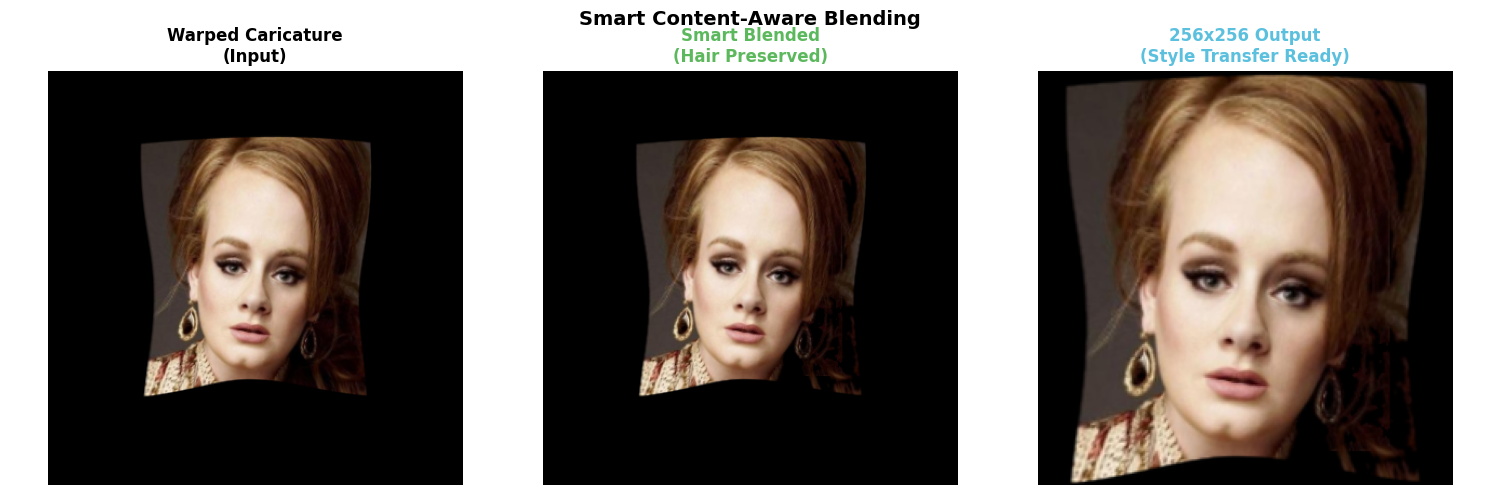


SUMMARY
✅ Smart content-aware blending completed!
📐 Center radius: 0.7 (70% center uses warped)
💡 Hair and edges properly preserved (no dark shading)
📏 Final 256x256 size achieved
💾 Saved to: D:\Projects 2025\Caricature Generation\data\caricatures_256x256
📦 Global variables: CARICATURE_256, CARICATURE_BLENDED

✅ Ready for style transfer!


In [15]:
# CELL 2: Smart Content Blending and Resize to 256x256
# Only blends where actual content exists, preserves hair properly

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# ==================== CHECK DATA AVAILABILITY ====================
if 'SAVED_WARPED_FULL' not in globals() or SAVED_WARPED_FULL is None:
    print("❌ Error: No data from previous cell!")
    print("📌 Please run Cell 1 first and click 'Save & Send to Blending'")
    raise RuntimeError("Missing data from Cell 1")

print(f"✓ Received original image: {SAVED_ORIGINAL_FULL.shape}")
print(f"✓ Received warped image: {SAVED_WARPED_FULL.shape}")

# ==================== SMART BLENDING FUNCTIONS ====================
def create_content_mask(img, black_threshold=15):
    """
    Create a binary mask of where actual content (non-black) exists.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    content_mask = (gray > black_threshold).astype(np.float32)
    
    # Slight blur to smooth edges
    content_mask = cv2.GaussianBlur(content_mask, (5, 5), 1.0)
    
    # Make 3-channel
    return np.stack([content_mask, content_mask, content_mask], axis=-1)

def create_center_blend_mask(img_shape, center_radius_ratio=0.6, edge_smoothness=0.1):
    """
    Create a mask that's 1.0 at center, smoothly transitions to 0 at edges.
    Only applied where content exists.
    """
    h, w = img_shape[:2]
    
    # Create distance map from center
    y, x = np.ogrid[:h, :w]
    center_y, center_x = h // 2, w // 2
    
    # Normalize distance to [0, 1]
    max_dist = np.sqrt((h/2)**2 + (w/2)**2)
    dist = np.sqrt((x - center_x)**2 + (y - center_y)**2) / max_dist
    
    # Create smooth transition: 1.0 at center, 0.0 at edges
    # center_radius_ratio controls where transition starts
    inner_radius = center_radius_ratio
    outer_radius = 1.0
    
    # Smooth step function
    mask = np.zeros_like(dist)
    mask[dist <= inner_radius] = 1.0
    
    transition_zone = (dist > inner_radius) & (dist < outer_radius)
    transition_dist = (dist[transition_zone] - inner_radius) / (outer_radius - inner_radius)
    # Smooth interpolation using cosine
    mask[transition_zone] = 0.5 * (1.0 + np.cos(np.pi * transition_dist))
    
    # Make it 3-channel
    mask = np.stack([mask, mask, mask], axis=-1).astype(np.float32)
    
    return mask

def smart_blend_images(img_warped, img_original, center_radius=0.7):
    """
    Smart blending that only affects content areas, not black background.
    Preserves hair and face details properly.
    """
    # Find where content exists in each image
    mask_warped = create_content_mask(img_warped)
    mask_original = create_content_mask(img_original)
    
    # Combined content mask (where either image has content)
    combined_content = np.maximum(mask_warped, mask_original)
    
    # Create center-to-edge blend mask
    center_blend = create_center_blend_mask(img_warped.shape, center_radius_ratio=center_radius)
    
    # Only apply blending where there's ACTUAL content
    # This prevents blending black backgrounds together
    final_blend_mask = center_blend * combined_content
    
    # Perform blending
    img1_f = img_warped.astype(np.float32)
    img2_f = img_original.astype(np.float32)
    
    # Where blend mask is 1.0: use warped
    # Where blend mask is 0.0: use original
    # In between: smooth blend
    blended = img1_f * final_blend_mask + img2_f * (1.0 - final_blend_mask)
    
    # Where there's NO content in both images, keep it black (0)
    no_content = (combined_content < 0.1)
    blended[no_content] = 0.0
    
    blended = np.clip(blended, 0, 255).astype(np.uint8)
    
    return blended

def find_content_bbox(img, black_threshold=15):
    """Find bounding box of actual content."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    content_mask = gray > black_threshold
    
    kernel = np.ones((5, 5), np.uint8)
    content_mask = cv2.morphologyEx(content_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
    
    coords = np.argwhere(content_mask)
    
    if len(coords) == 0:
        h, w = img.shape[:2]
        return 0, 0, w, h
    
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    
    h, w = img.shape[:2]
    margin = 2
    y_min = max(0, y_min - margin)
    x_min = max(0, x_min - margin)
    y_max = min(h, y_max + margin)
    x_max = min(w, x_max + margin)
    
    return x_min, y_min, x_max, y_max

def resize_with_black_canvas(img, target_size=256):
    """Resize to target_size x target_size with black canvas."""
    x_min, y_min, x_max, y_max = find_content_bbox(img)
    content = img[y_min:y_max, x_min:x_max]
    
    h, w = content.shape[:2]
    scale = min(target_size / h, target_size / w)
    
    new_h = int(h * scale)
    new_w = int(w * scale)
    
    resized = cv2.resize(content, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)
    
    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)
    
    y_offset = (target_size - new_h) // 2
    x_offset = (target_size - new_w) // 2
    
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    
    return canvas

# ==================== BLENDING PARAMETERS ====================
BLEND_PARAMS = {
    'center_radius': 0.7,  # Radius where warped is fully used (0.0-1.0)
    # 0.7 means center 70% uses warped, outer 30% smoothly blends to original
}

# ==================== PERFORM SMART BLENDING ====================
print("\n" + "="*60)
print("SMART CONTENT-AWARE BLENDING")
print("="*60)

# Ensure same size
if SAVED_WARPED_FULL.shape != SAVED_ORIGINAL_FULL.shape:
    print(f"⚠️ Size mismatch, resizing original to match warped...")
    h, w = SAVED_WARPED_FULL.shape[:2]
    SAVED_ORIGINAL_FULL = cv2.resize(SAVED_ORIGINAL_FULL, (w, h), interpolation=cv2.INTER_LANCZOS4)

print(f"\n🎨 Blending only where content exists (preserves hair)...")
print(f"   Center radius: {BLEND_PARAMS['center_radius']} (warped fully used in center 70%)")

blended_result = smart_blend_images(
    SAVED_WARPED_FULL, 
    SAVED_ORIGINAL_FULL, 
    center_radius=BLEND_PARAMS['center_radius']
)

print(f"✅ Blending complete - hair and details preserved!")

# ==================== RESIZE TO 256x256 ====================
print("\n" + "="*60)
print("RESIZE TO 256x256")
print("="*60)

print(f"🔍 Resizing to 256x256 with black canvas...")
result_256 = resize_with_black_canvas(blended_result, target_size=256)

print(f"✓ Final size: {result_256.shape}")

# ==================== SAVE RESULTS ====================
output_dir = Path(DATA_ALIGNED).parent / "caricatures_256x256"
output_dir.mkdir(parents=True, exist_ok=True)

base_name = demo_img_path.stem.replace('_aligned', '')

# Save blended full-size result
blended_path = output_dir / f"{base_name}_blended_full.png"
Image.fromarray(blended_result).save(str(blended_path))

# Save 256x256 result
output_path = output_dir / f"{base_name}_caricature_256x256.png"
Image.fromarray(result_256).save(str(output_path))

print(f"\n💾 Saved blended (full): {blended_path.name}")
print(f"💾 Saved 256x256: {output_path.name}")

# Global variables for next steps
CARICATURE_256 = result_256
CARICATURE_BLENDED = blended_result

# ==================== VISUALIZATION ====================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Warped (input)
axes[0].imshow(SAVED_WARPED_FULL)
axes[0].set_title('Warped Caricature\n(Input)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Blended (output)
axes[1].imshow(blended_result)
axes[1].set_title('Smart Blended\n(Hair Preserved)', fontsize=12, fontweight='bold', color='#5cb85c')
axes[1].axis('off')

# 256x256 final
axes[2].imshow(result_256)
axes[2].set_title('256x256 Output\n(Style Transfer Ready)', fontsize=12, fontweight='bold', color='#5bc0de')
axes[2].axis('off')

plt.suptitle('Smart Content-Aware Blending', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ==================== SUMMARY ====================
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"✅ Smart content-aware blending completed!")
print(f"📐 Center radius: {BLEND_PARAMS['center_radius']} (70% center uses warped)")
print(f"💡 Hair and edges properly preserved (no dark shading)")
print(f"📏 Final 256x256 size achieved")
print(f"💾 Saved to: {output_dir}")
print(f"📦 Global variables: CARICATURE_256, CARICATURE_BLENDED")
print(f"\n✅ Ready for style transfer!")
print("="*60)